In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score


In [2]:
data = pd.read_csv("diabetes.csv")
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
data.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
corr=data.corr()
corr

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


In [7]:
print(data.shape)

(768, 9)


In [8]:
data.size 

6912

In [9]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Text(0, 0.5, 'No. of Athlete')

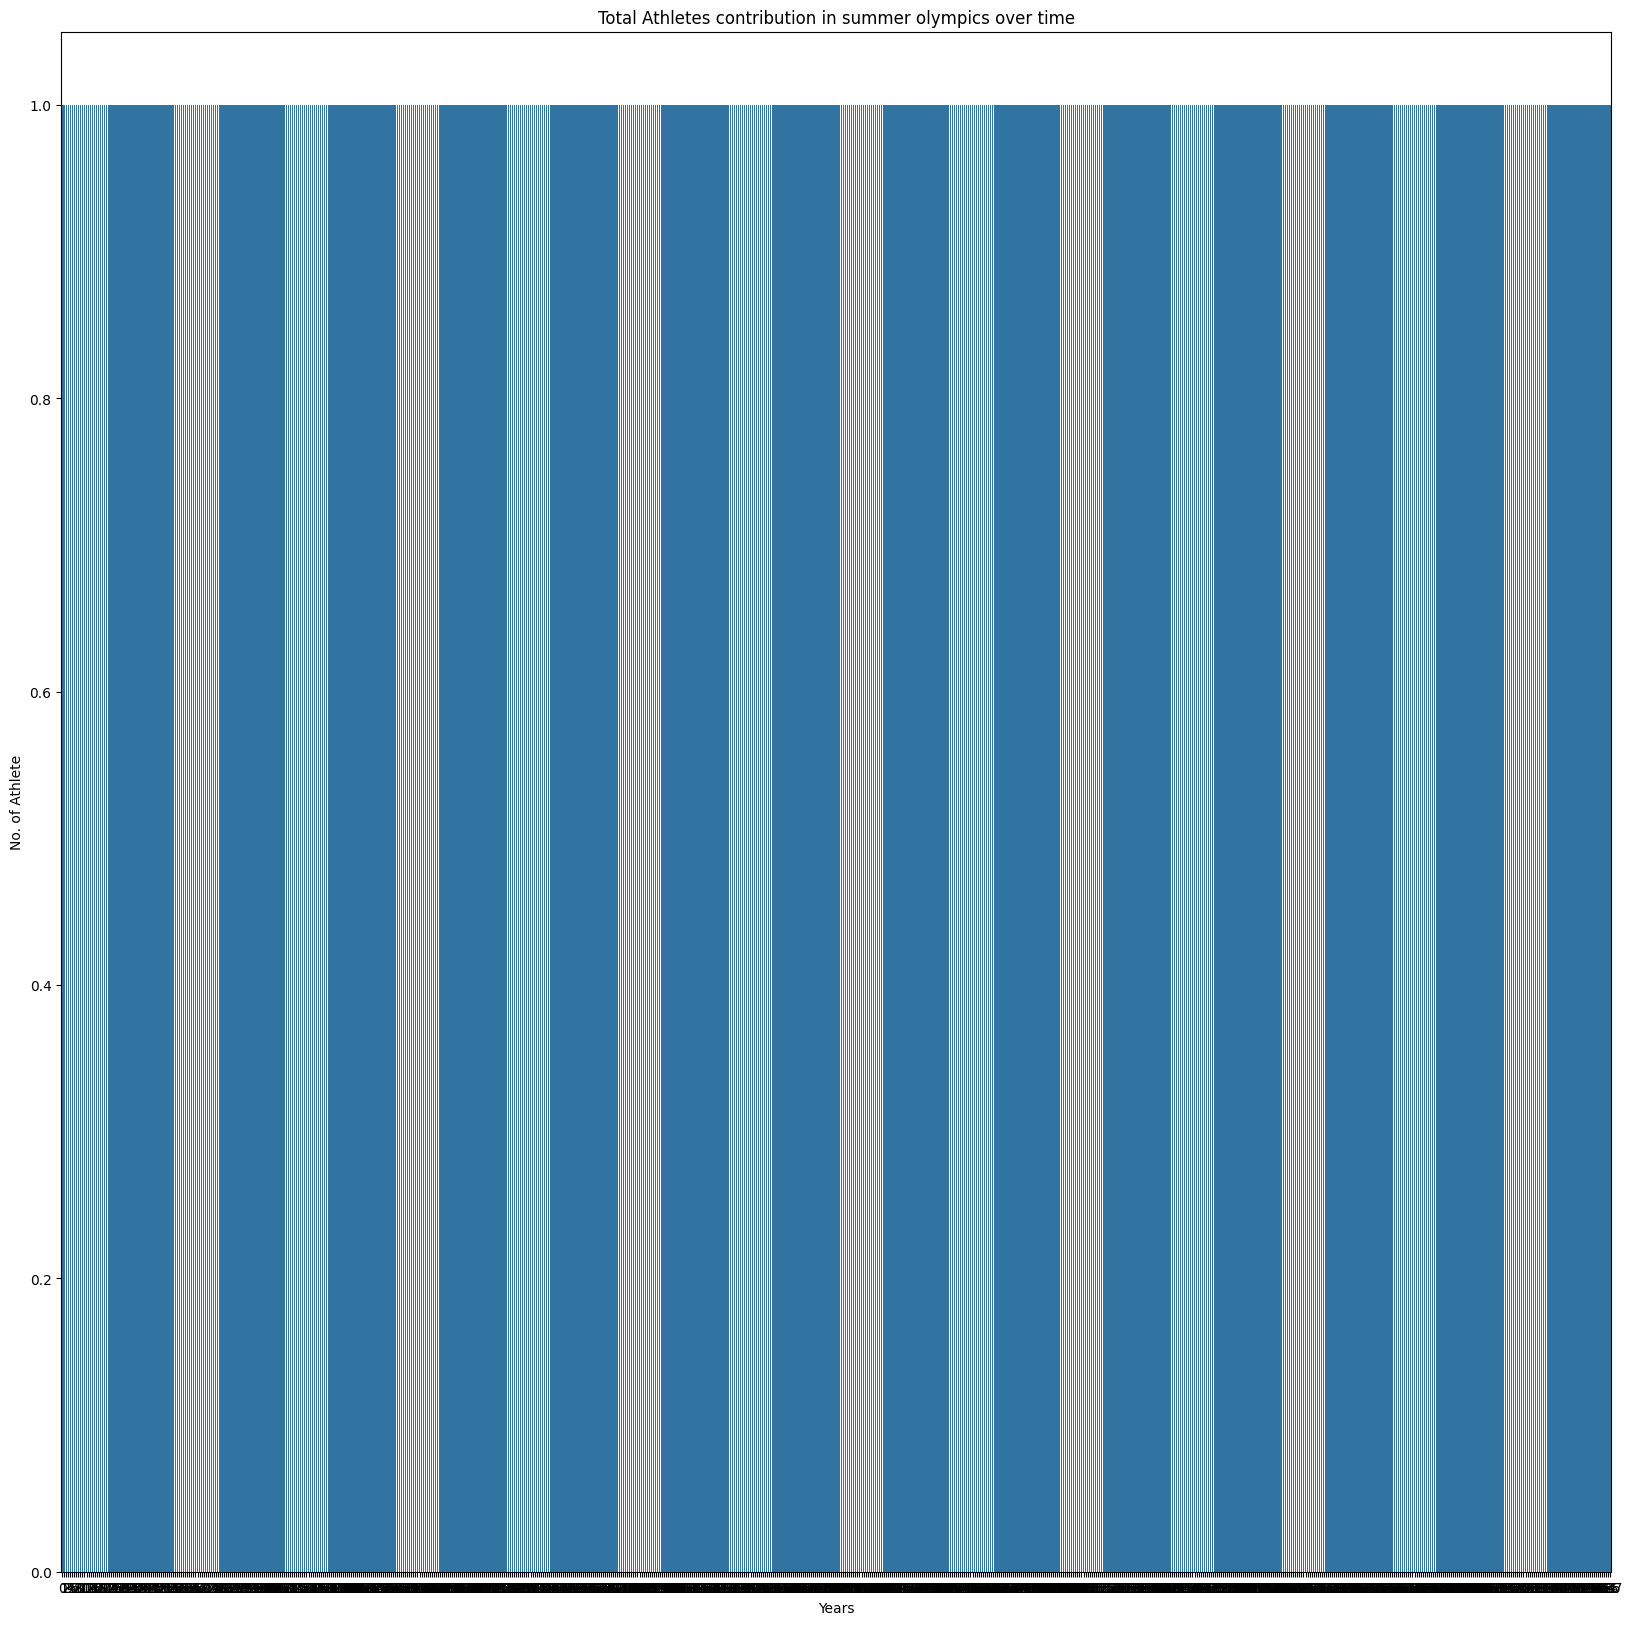

In [10]:
plt.figure(figsize=(20, 20))
sns.countplot(data['Age'])
plt.title('Total Athletes contribution in summer olympics over time')
plt.xlabel('Years')
plt.ylabel('No. of Athlete')

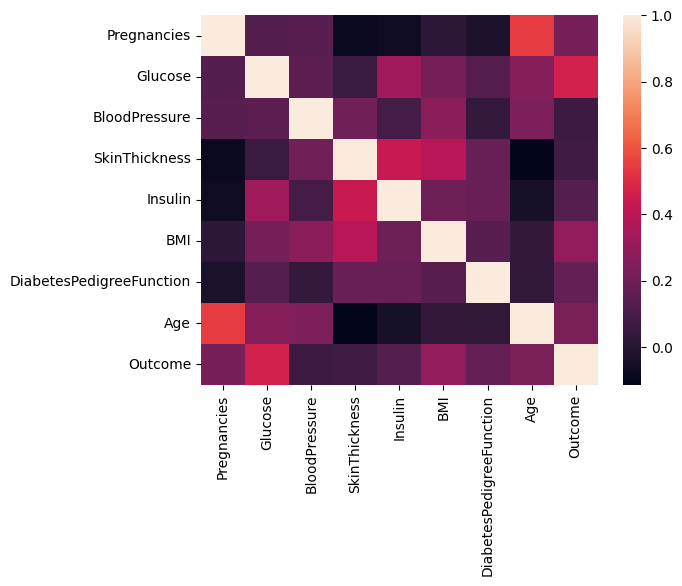

In [11]:
sns.heatmap(data.corr())
plt.show()

<Axes: xlabel='Outcome', ylabel='count'>

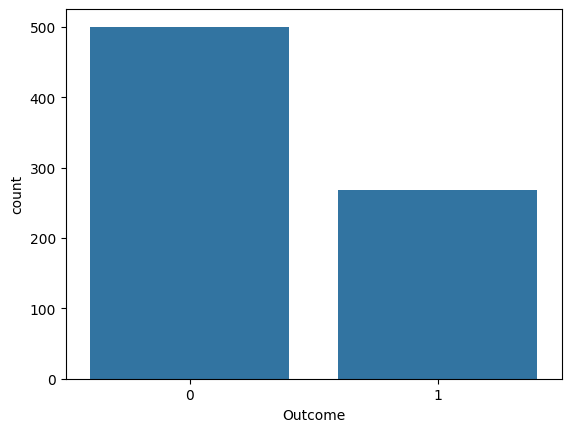

In [12]:
sns.countplot(x = 'Outcome',data = data)

<Axes: xlabel='Age', ylabel='count'>

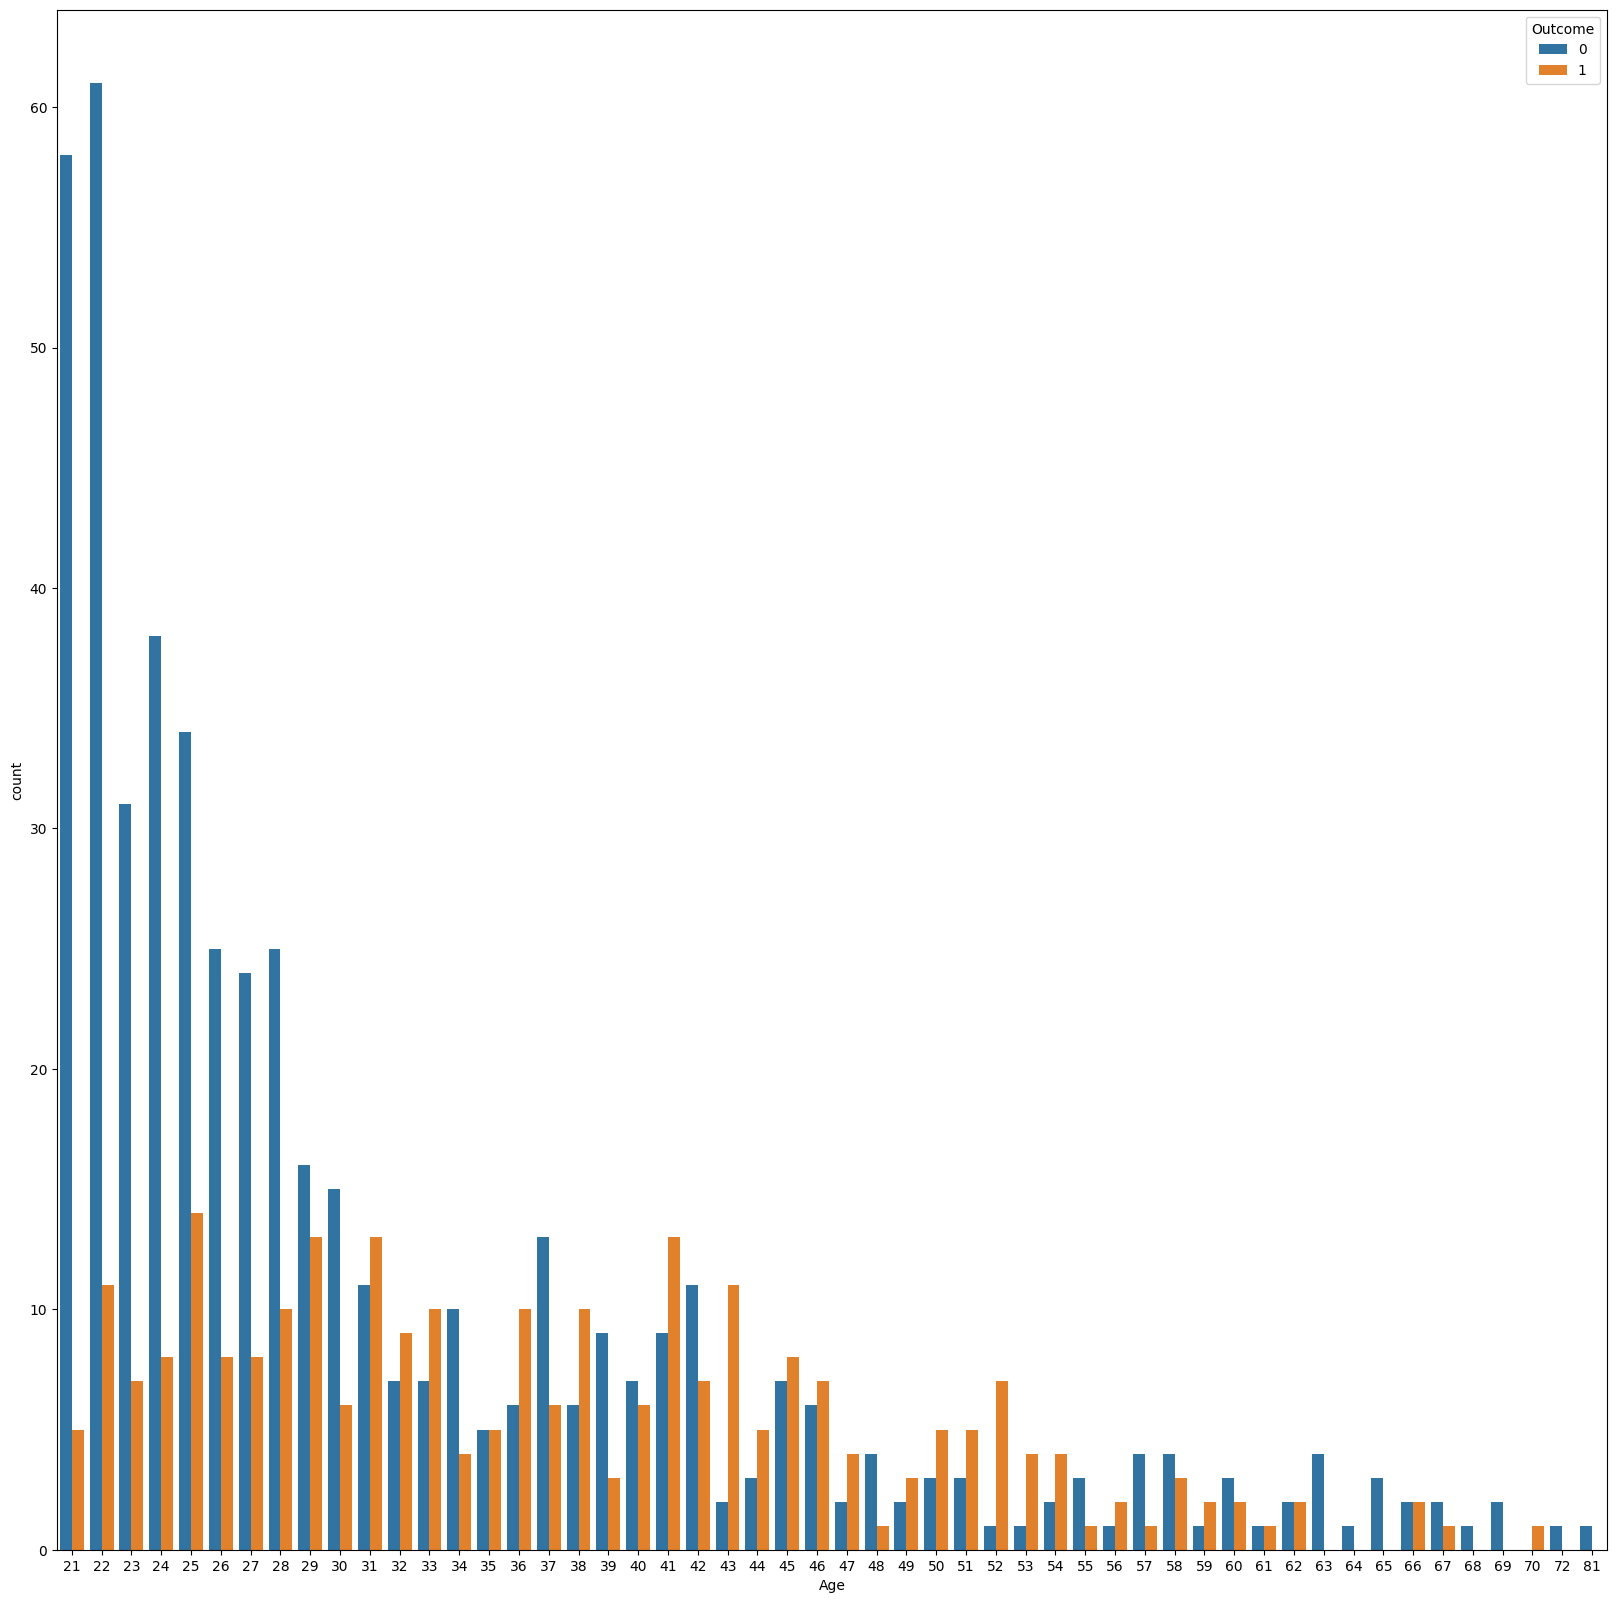

In [13]:
plt.figure(figsize=(20, 20))
sns.countplot(x = 'Age',hue='Outcome', data = data)

array([[<Axes: title={'center': 'Pregnancies'}>,
        <Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BloodPressure'}>],
       [<Axes: title={'center': 'SkinThickness'}>,
        <Axes: title={'center': 'Insulin'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'DiabetesPedigreeFunction'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Outcome'}>]], dtype=object)

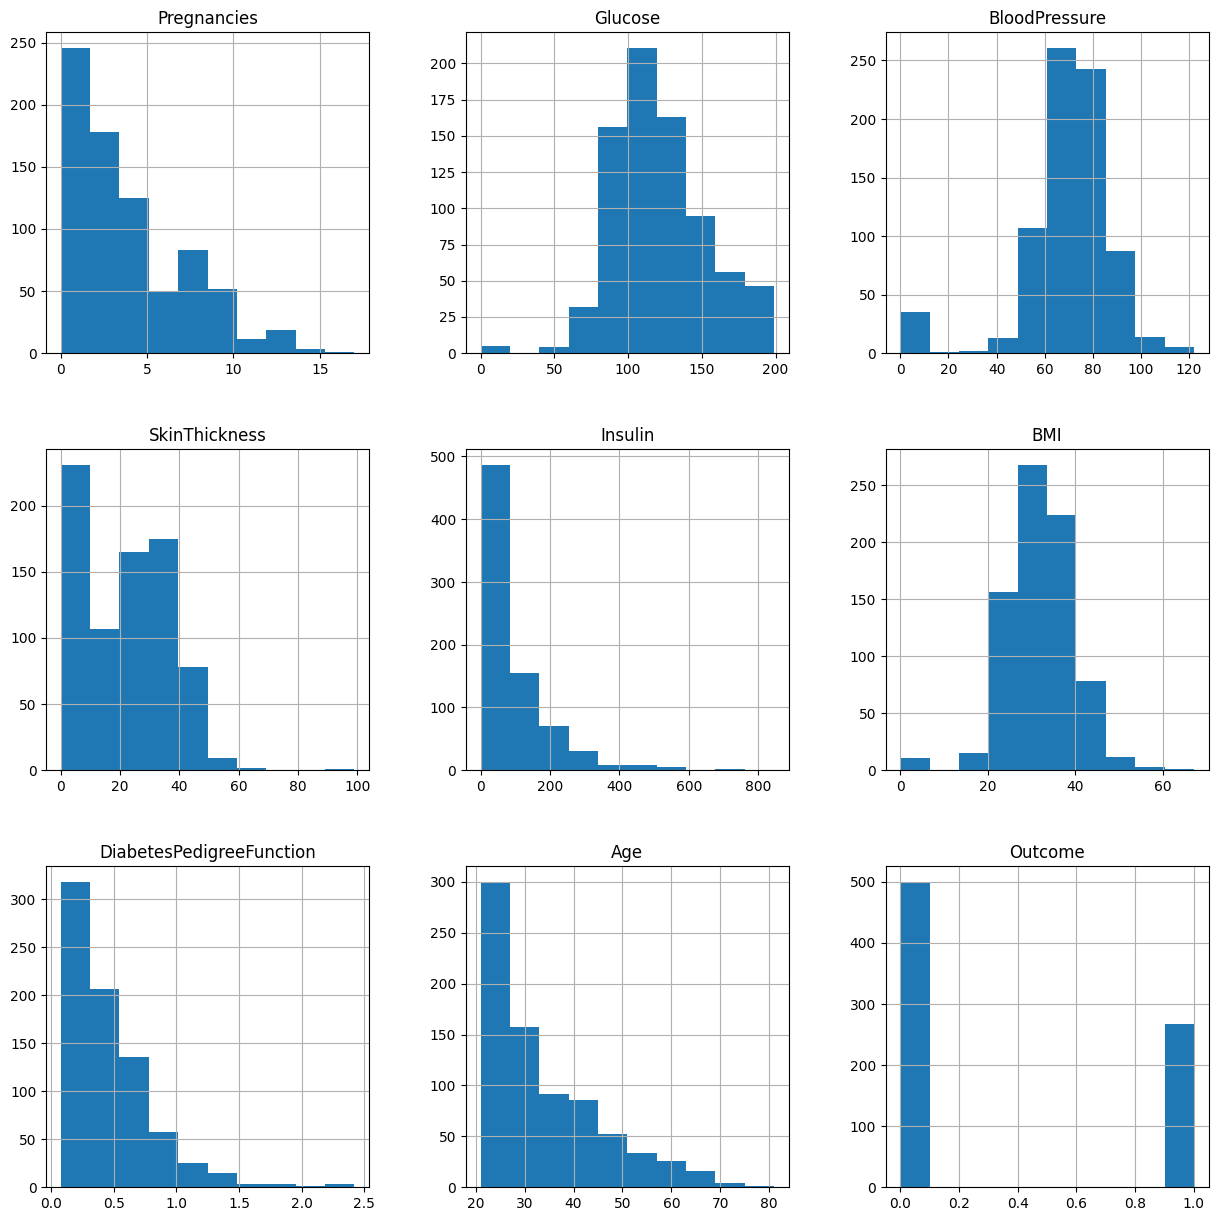

In [14]:
data.hist(figsize=(15, 15))

e:\python\venv\Lib\site-packages\seaborn\_base.py:1608: UserWarning: Vertical orientation ignored with only `x` specified.
  warnings.warn(single_var_warning.format("Vertical", "x"))
e:\python\venv\Lib\site-packages\seaborn\_base.py:1608: UserWarning: Vertical orientation ignored with only `x` specified.
  warnings.warn(single_var_warning.format("Vertical", "x"))
e:\python\venv\Lib\site-packages\seaborn\_base.py:1608: UserWarning: Vertical orientation ignored with only `x` specified.
  warnings.warn(single_var_warning.format("Vertical", "x"))
e:\python\venv\Lib\site-packages\seaborn\_base.py:1608: UserWarning: Vertical orientation ignored with only `x` specified.
  warnings.warn(single_var_warning.format("Vertical", "x"))
e:\python\venv\Lib\site-packages\seaborn\_base.py:1608: UserWarning: Vertical orientation ignored with only `x` specified.
  warnings.warn(single_var_warning.format("Vertical", "x"))
e:\python\venv\Lib\site-packages\seaborn\_base.py:1608: UserWarning: Vertical orienta

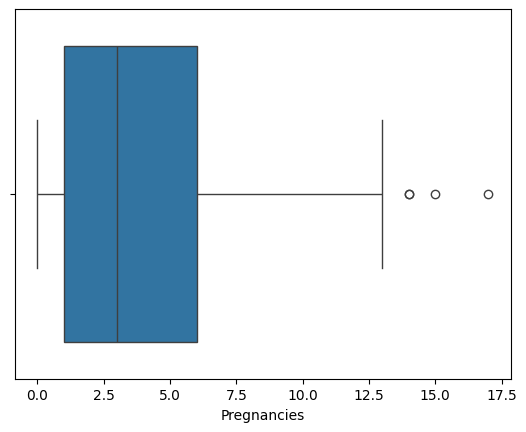

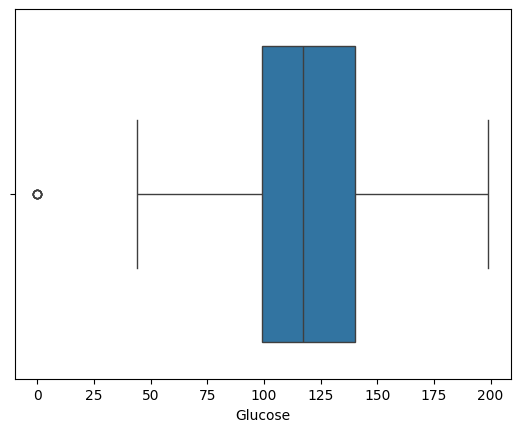

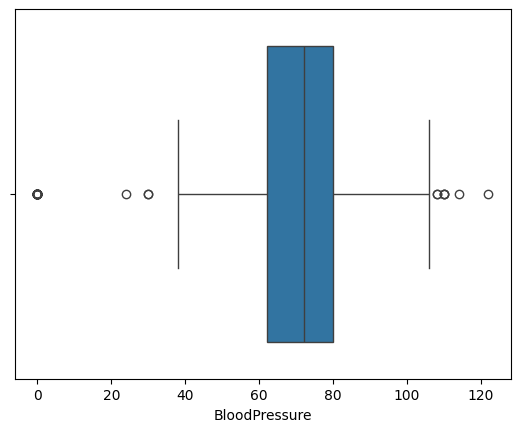

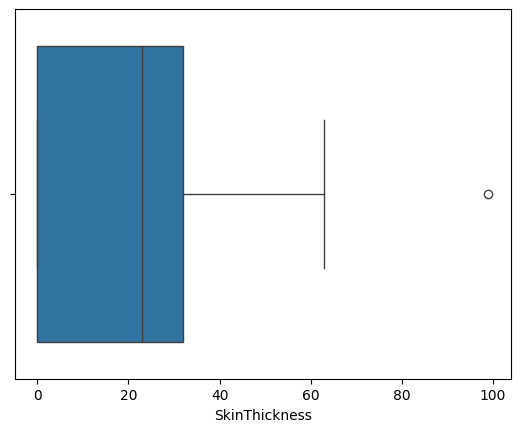

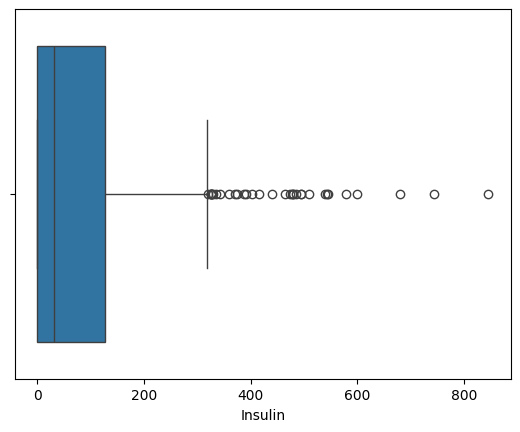

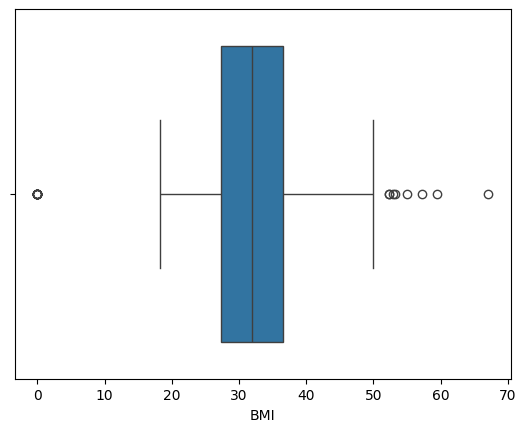

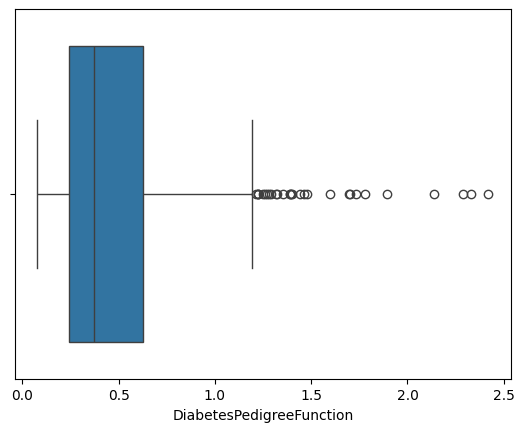

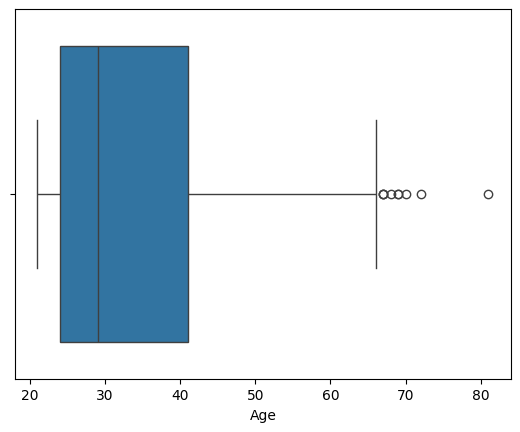

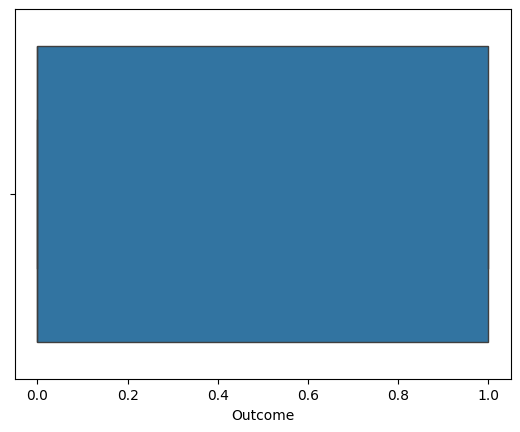

In [15]:
for c in data.columns:
    plt.figure()
    sns.boxplot(x = c, data = data, orient = "v")
    

C:\Users\Admin\AppData\Local\Temp\ipykernel_12036\3225033659.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[i])


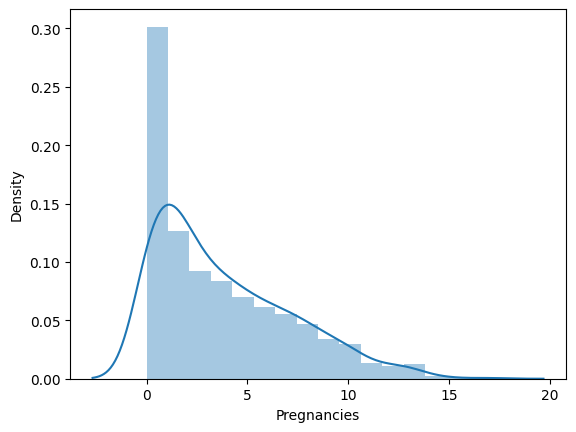

C:\Users\Admin\AppData\Local\Temp\ipykernel_12036\3225033659.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[i])


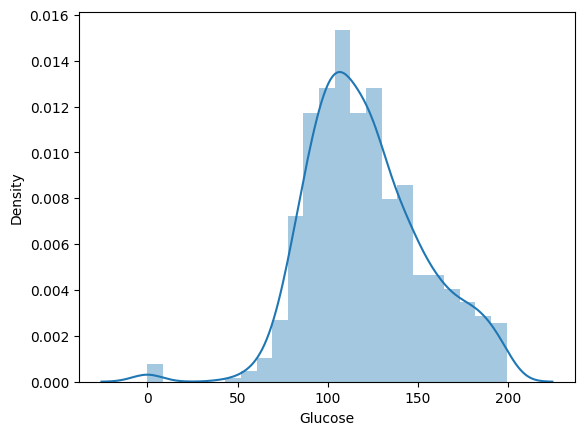

C:\Users\Admin\AppData\Local\Temp\ipykernel_12036\3225033659.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[i])


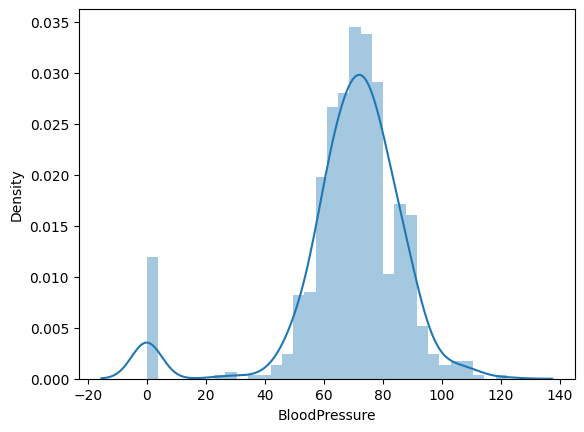

C:\Users\Admin\AppData\Local\Temp\ipykernel_12036\3225033659.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[i])


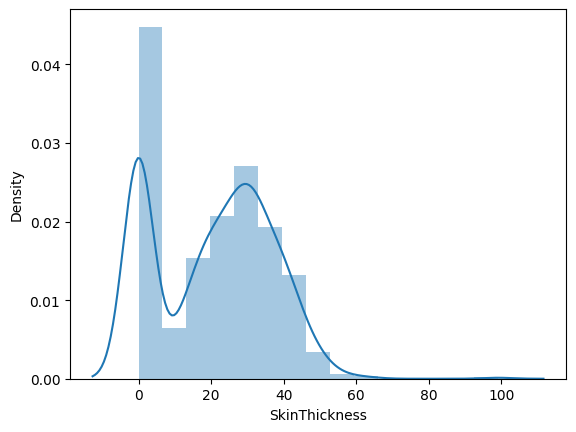

C:\Users\Admin\AppData\Local\Temp\ipykernel_12036\3225033659.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[i])


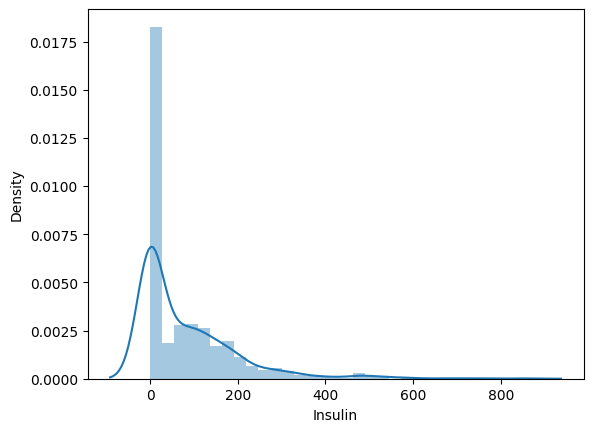

C:\Users\Admin\AppData\Local\Temp\ipykernel_12036\3225033659.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[i])


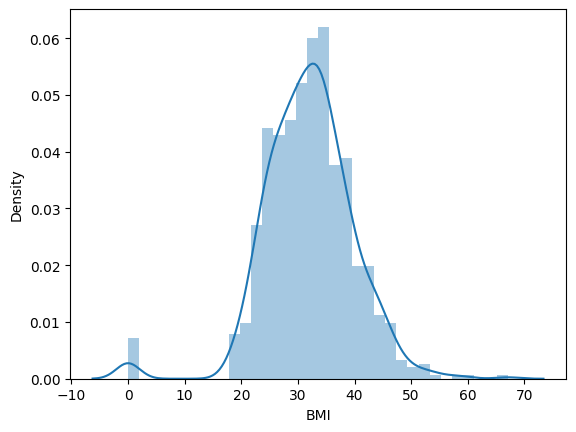

C:\Users\Admin\AppData\Local\Temp\ipykernel_12036\3225033659.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[i])


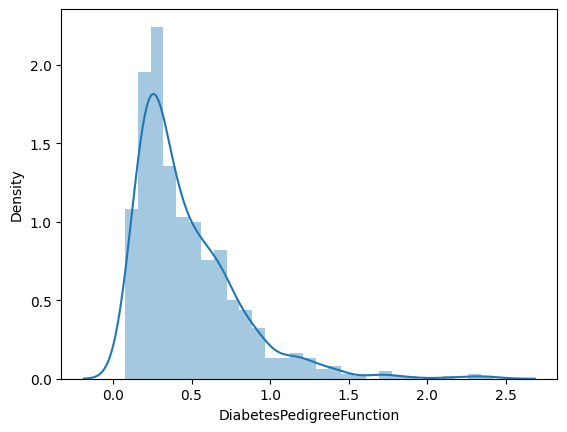

C:\Users\Admin\AppData\Local\Temp\ipykernel_12036\3225033659.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[i])


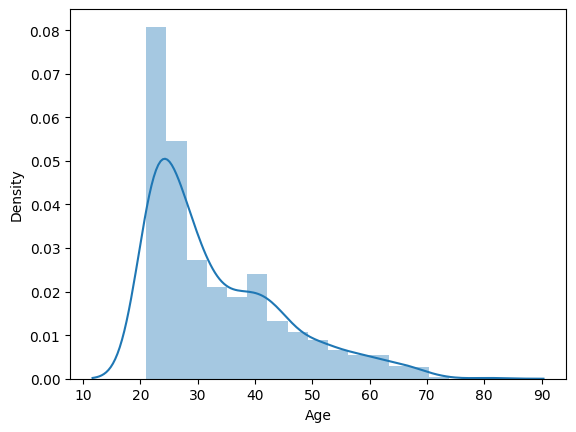

C:\Users\Admin\AppData\Local\Temp\ipykernel_12036\3225033659.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[i])


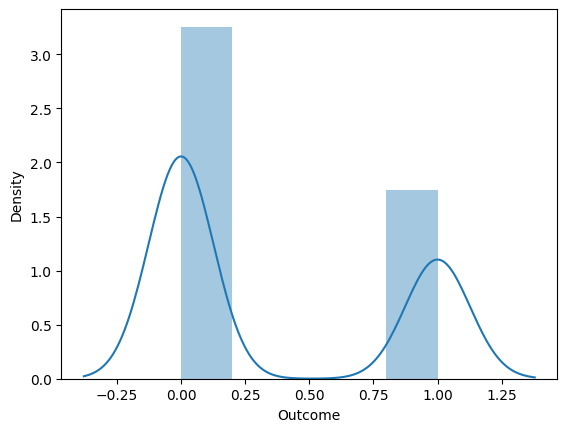

In [16]:
for i in data.columns:
    plt.figure()
    sns.distplot(data[i])
    plt.show()
    

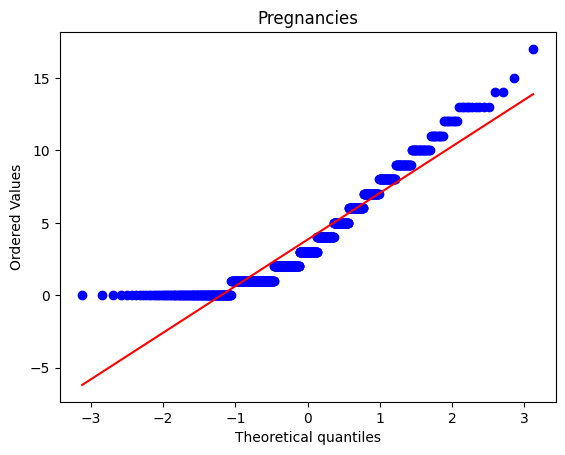

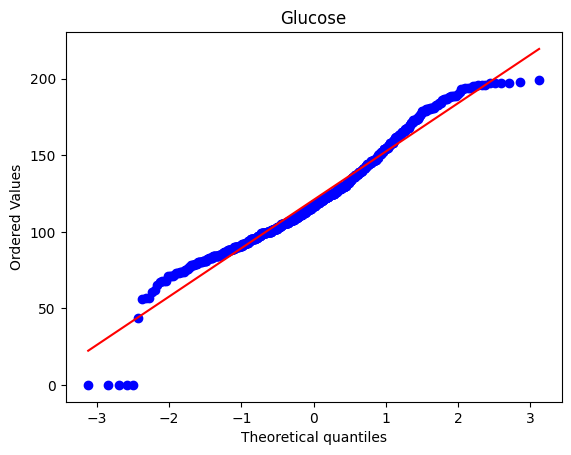

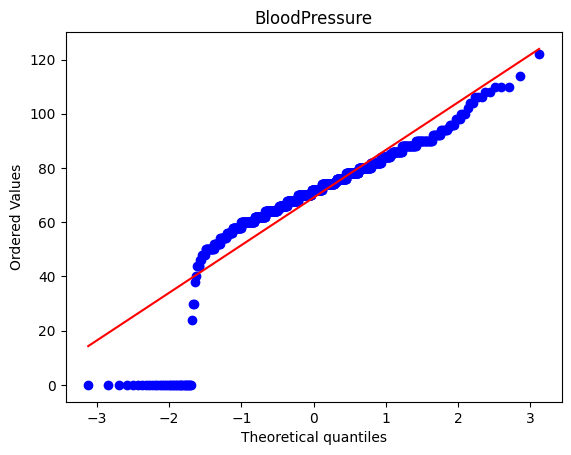

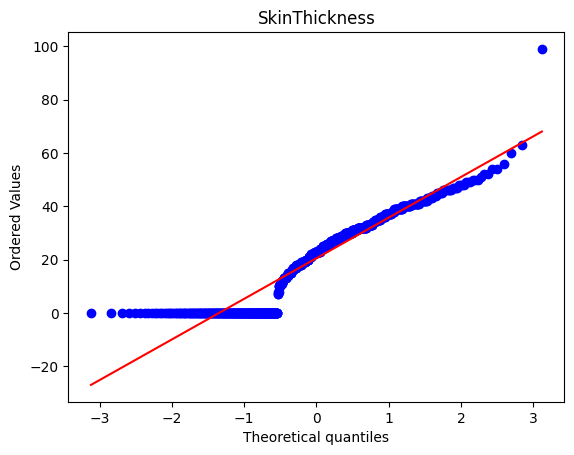

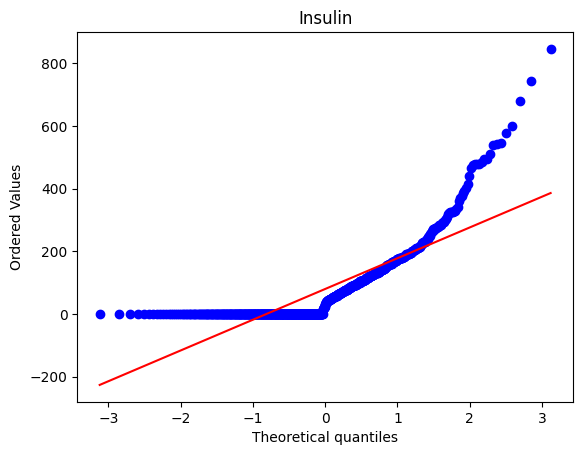

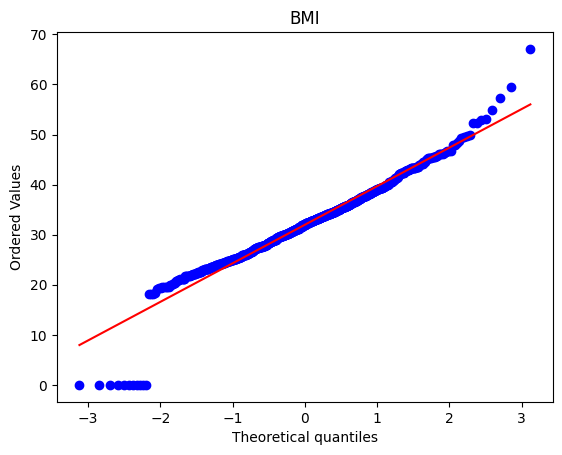

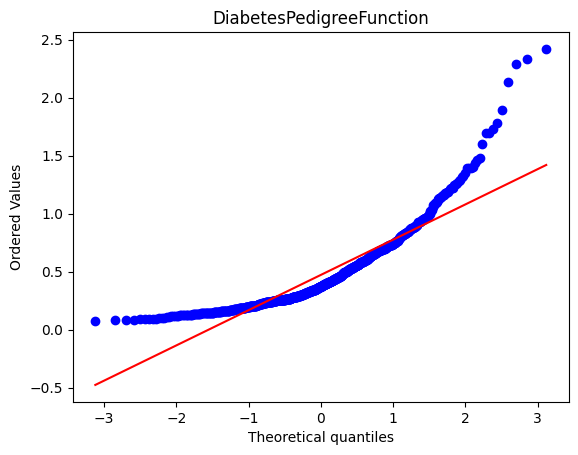

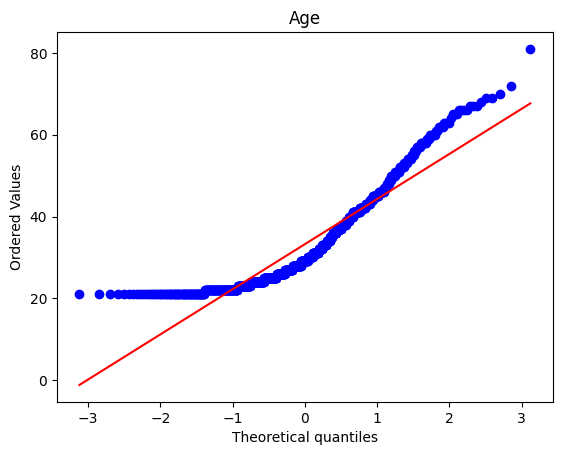

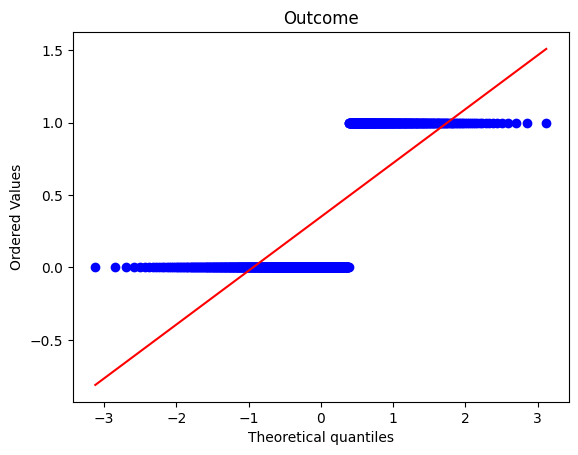

In [17]:
for i in data.columns:
    plt.figure()
    stats.probplot(data[i], plot = plt)
    plt.title(i)
    plt.show()

In [18]:
x = data.drop(columns = "Outcome")
y = data["Outcome"]

In [19]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=0)

In [20]:
print('X train shape: ', x_train.shape)
print('Y train shape: ', y_train.shape)
print('X test shape: ', y_test.shape)
print('Y test shape: ', y_test.shape)

X train shape:  (614, 8)
Y train shape:  (614,)
X test shape:  (154,)
Y test shape:  (154,)


minmax

In [21]:
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()
x_train_min= mms.fit_transform(x_train)
x_test_min = mms.transform(x_test)

0.7597402597402597
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       102
           1       0.66      0.60      0.63        52

    accuracy                           0.76       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.76      0.76      0.76       154

F1 is:  0.6262626262626263


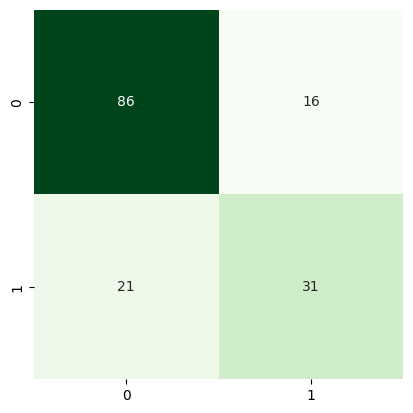

In [22]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(x_train_min,y_train)

dt_pred = dt.predict(x_test_min)

dt_acc = accuracy_score(dt_pred,y_test)
print(dt_acc)

clf_report = classification_report(dt_pred,y_test)
print(clf_report)

cm = confusion_matrix(dt_pred,y_test)
sns.heatmap(cm, square=True, annot=True, cmap='Greens', fmt='d', cbar=False)

print('F1 is: ', f1_score(dt_pred,y_test))

0.7597402597402597
              precision    recall  f1-score   support

         0.0       0.79      0.85      0.82       100
         1.0       0.68      0.59      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.73       154
weighted avg       0.75      0.76      0.76       154

F1 is:  0.6336633663366337


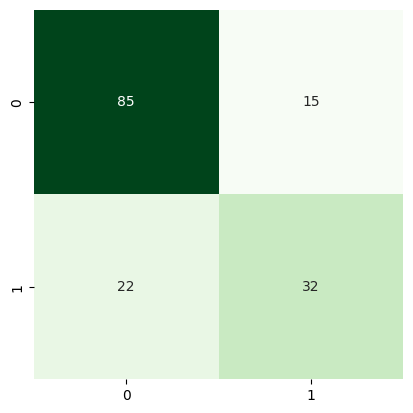

In [23]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor()
dt.fit(x_train_min,y_train)

dt_pred = dt.predict(x_test_min)

dt_acc = accuracy_score(dt_pred,y_test)
print(dt_acc)

clf_report = classification_report(dt_pred,y_test)
print(clf_report)

cm = confusion_matrix(dt_pred,y_test)
sns.heatmap(cm, square=True, annot=True, cmap='Greens', fmt='d', cbar=False)

print('F1 is: ', f1_score(dt_pred,y_test))

0.8116883116883117
              precision    recall  f1-score   support

           0       0.89      0.85      0.87       112
           1       0.64      0.71      0.67        42

    accuracy                           0.81       154
   macro avg       0.76      0.78      0.77       154
weighted avg       0.82      0.81      0.81       154

F1 is:  0.6741573033707865


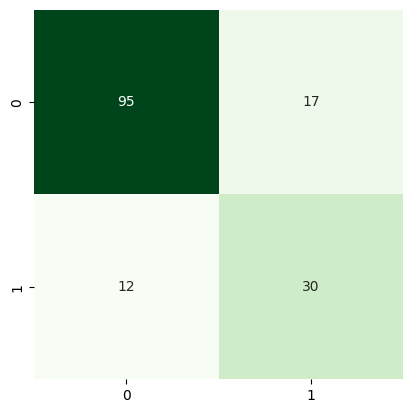

In [24]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100)
rf.fit(x_train_min,y_train)

rf_pred = rf.predict(x_test_min)

rf_acc = accuracy_score(rf_pred,y_test)
print(rf_acc)

clf_report = classification_report(rf_pred,y_test)
print(clf_report)

cm = confusion_matrix(rf_pred,y_test)
sns.heatmap(cm, square=True, annot=True, cmap='Greens', fmt='d', cbar=False)

print('F1 is: ', f1_score(rf_pred,y_test))

0.8181818181818182
              precision    recall  f1-score   support

           0       0.93      0.83      0.88       119
           1       0.57      0.77      0.66        35

    accuracy                           0.82       154
   macro avg       0.75      0.80      0.77       154
weighted avg       0.85      0.82      0.83       154

F1 is:  0.6585365853658537


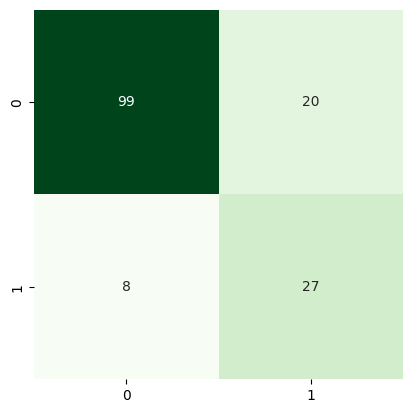

In [25]:
from sklearn.linear_model import LogisticRegression 
lr=LogisticRegression()
lr.fit(x_train_min,y_train)

#predicting
lr_predict=lr.predict(x_test_min)

lr_acc=accuracy_score(y_test,lr_predict)
print(lr_acc)

clf_report = classification_report(lr_predict,y_test)
print(clf_report)

cm = confusion_matrix(lr_predict,y_test)
sns.heatmap(cm, square=True, annot=True, cmap='Greens', fmt='d', cbar=False)

print('F1 is: ', f1_score(lr_predict,y_test))

0.7792207792207793
              precision    recall  f1-score   support

           0       0.91      0.80      0.85       121
           1       0.49      0.70      0.57        33

    accuracy                           0.78       154
   macro avg       0.70      0.75      0.71       154
weighted avg       0.82      0.78      0.79       154

F1 is:  0.575


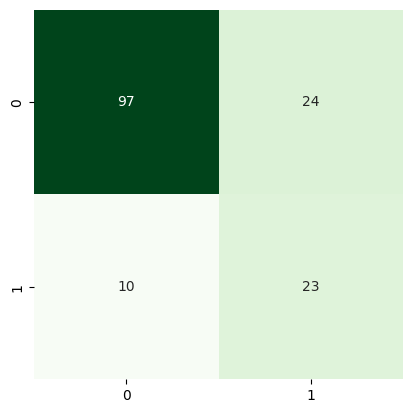

In [26]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 10)
knn.fit(x_train_min,y_train)

knn_pred = knn.predict(x_test_min)

knn_acc = accuracy_score(knn_pred,y_test)
print(knn_acc)

clf_report = classification_report(knn_pred,y_test)
print(clf_report)

cm = confusion_matrix(knn_pred,y_test)
sns.heatmap(cm, square=True, annot=True, cmap='Greens', fmt='d', cbar=False)

print('F1 is: ', f1_score(knn_pred,y_test))

0.7987012987012987
              precision    recall  f1-score   support

           0       0.91      0.82      0.86       118
           1       0.55      0.72      0.63        36

    accuracy                           0.80       154
   macro avg       0.73      0.77      0.74       154
weighted avg       0.82      0.80      0.81       154

F1 is:  0.6265060240963856


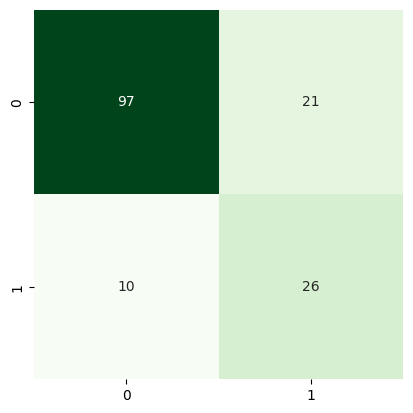

In [27]:
from sklearn.svm import SVC
svm = SVC()
svm.fit(x_train_min,y_train)

svm_pred = svm.predict(x_test_min)

svm_acc = accuracy_score(svm_pred,y_test)
print(svm_acc)

clf_report = classification_report(svm_pred,y_test)
print(clf_report)

cm = confusion_matrix(svm_pred,y_test)
sns.heatmap(cm, square=True, annot=True, cmap='Greens', fmt='d', cbar=False)

print('F1 is: ', f1_score(svm_pred,y_test))

0.7922077922077922
              precision    recall  f1-score   support

           0       0.87      0.84      0.85       111
           1       0.62      0.67      0.64        43

    accuracy                           0.79       154
   macro avg       0.74      0.76      0.75       154
weighted avg       0.80      0.79      0.79       154



F1 is:  0.6444444444444445


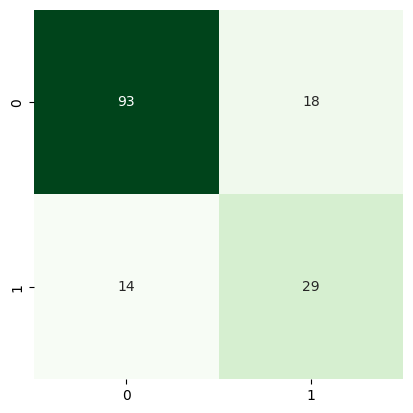

In [28]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(x_train_min,y_train)

nb_pred = nb.predict(x_test_min)

nb_acc = accuracy_score(nb_pred,y_test)
print(nb_acc)

clf_report = classification_report(nb_pred,y_test)
print(clf_report)

cm = confusion_matrix(nb_pred,y_test)
sns.heatmap(cm, square=True, annot=True, cmap='Greens', fmt='d', cbar=False)

print('F1 is: ', f1_score(nb_pred,y_test))

0.8181818181818182
              precision    recall  f1-score   support

           0       0.93      0.83      0.88       121
           1       0.55      0.79      0.65        33

    accuracy                           0.82       154
   macro avg       0.74      0.81      0.76       154
weighted avg       0.85      0.82      0.83       154

F1 is:  0.65


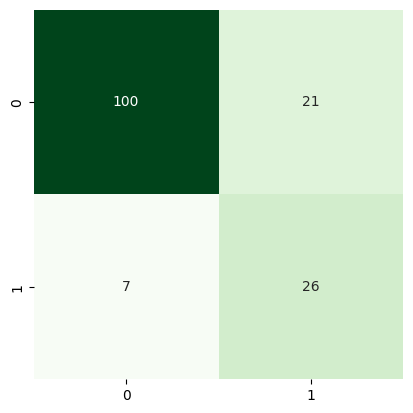

In [29]:
from sklearn.linear_model import SGDClassifier
sgd = SGDClassifier()
sgd.fit(x_train_min,y_train)

sgd_pred = sgd.predict(x_test_min)

sgd_acc = accuracy_score(sgd_pred,y_test)
print(sgd_acc)

clf_report = classification_report(sgd_pred,y_test)
print(clf_report)

cm = confusion_matrix(sgd_pred,y_test)
sns.heatmap(cm, square=True, annot=True, cmap='Greens', fmt='d', cbar=False)

print('F1 is: ', f1_score(sgd_pred,y_test))

In [30]:
models = []
from sklearn.metrics import accuracy_score

models.append(('KNN', KNeighborsClassifier()))
models.append(('DT', DecisionTreeClassifier()))
models.append(('RF', RandomForestClassifier()))
models.append(('LR', LogisticRegression()))
models.append(('SVC', SVC()))
models.append(('NB', GaussianNB()))
models.append(('SGD', SGDClassifier()))


names = []
scores = []
for name, model in models:
    model.fit(x_train_min, y_train)
    y_pred = model.predict(x_test_min)
    scores.append(accuracy_score(y_pred, y_test))
    names.append(name)
tr_split = pd.DataFrame({'Name': names, 'Score': scores})
print(tr_split)

  Name     Score
0  KNN  0.779221
1   DT  0.792208
2   RF  0.805195
3   LR  0.818182
4  SVC  0.798701
5   NB  0.792208
6  SGD  0.759740


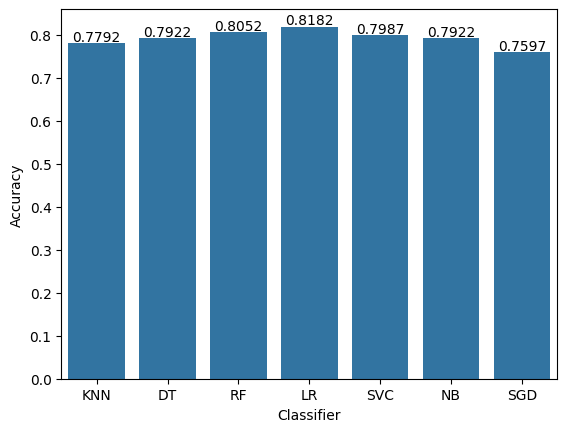

In [31]:

axis = sns.barplot(x = 'Name', y = 'Score', data =tr_split )
axis.set(xlabel='Classifier', ylabel='Accuracy')
for p in axis.patches:
    height = p.get_height()
    axis.text(p.get_x() + p.get_width()/2, height + 0.005, '{:1.4f}'.format(height), ha="center") 
    
plt.show()

PCA

In [32]:
from sklearn.decomposition import PCA
mms=PCA()
x_train_pca = mms.fit_transform(x_train)
x_test_pca = mms.transform(x_test)

0.7142857142857143
              precision    recall  f1-score   support

           0       0.74      0.83      0.78        95
           1       0.66      0.53      0.58        59

    accuracy                           0.71       154
   macro avg       0.70      0.68      0.68       154
weighted avg       0.71      0.71      0.71       154

F1 is:  0.5849056603773585


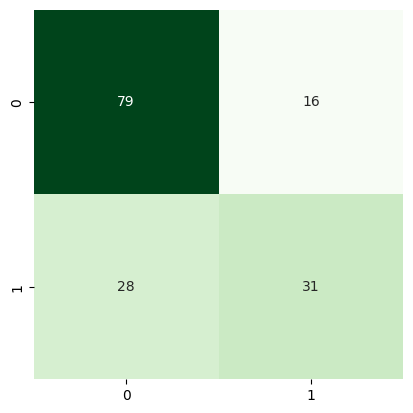

In [33]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(x_train_pca,y_train)

dt_pred = dt.predict(x_test_pca)

dt_acc = accuracy_score(dt_pred,y_test)
print(dt_acc)

clf_report = classification_report(dt_pred,y_test)
print(clf_report)

cm = confusion_matrix(dt_pred,y_test)
sns.heatmap(cm, square=True, annot=True, cmap='Greens', fmt='d', cbar=False)

print('F1 is: ', f1_score(dt_pred,y_test))

0.7012987012987013
              precision    recall  f1-score   support

         0.0       0.73      0.82      0.77        95
         1.0       0.64      0.51      0.57        59

    accuracy                           0.70       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.69      0.70      0.69       154

F1 is:  0.5660377358490566


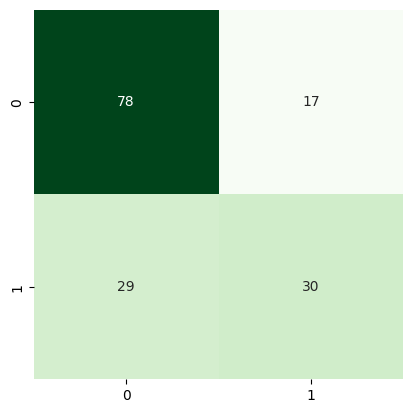

In [34]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor()
dt.fit(x_train_pca,y_train)

dt_pred = dt.predict(x_test_pca)

dt_acc = accuracy_score(dt_pred,y_test)
print(dt_acc)

clf_report = classification_report(dt_pred,y_test)
print(clf_report)

cm = confusion_matrix(dt_pred,y_test)
sns.heatmap(cm, square=True, annot=True, cmap='Greens', fmt='d', cbar=False)

print('F1 is: ', f1_score(dt_pred,y_test))

0.8116883116883117
              precision    recall  f1-score   support

           0       0.87      0.86      0.87       108
           1       0.68      0.70      0.69        46

    accuracy                           0.81       154
   macro avg       0.78      0.78      0.78       154
weighted avg       0.81      0.81      0.81       154

F1 is:  0.6881720430107527


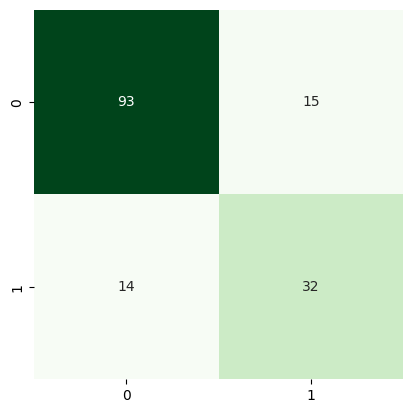

In [35]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100)
rf.fit(x_train_pca,y_train)

rf_pred = rf.predict(x_test_pca)

rf_acc = accuracy_score(rf_pred,y_test)
print(rf_acc)

clf_report = classification_report(rf_pred,y_test)
print(clf_report)

cm = confusion_matrix(rf_pred,y_test)
sns.heatmap(cm, square=True, annot=True, cmap='Greens', fmt='d', cbar=False)

print('F1 is: ', f1_score(rf_pred,y_test))

0.8246753246753247
              precision    recall  f1-score   support

           0       0.92      0.84      0.88       116
           1       0.62      0.76      0.68        38

    accuracy                           0.82       154
   macro avg       0.77      0.80      0.78       154
weighted avg       0.84      0.82      0.83       154

F1 is:  0.6823529411764706


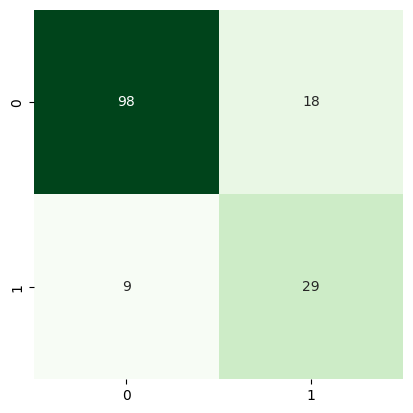

In [36]:
from sklearn.linear_model import LogisticRegression 
lr=LogisticRegression()
lr.fit(x_train_pca,y_train)

#predicting
lr_predict=lr.predict(x_test_pca)

lr_acc=accuracy_score(y_test,lr_predict)
print(lr_acc)

clf_report = classification_report(lr_predict,y_test)
print(clf_report)

cm = confusion_matrix(lr_predict,y_test)
sns.heatmap(cm, square=True, annot=True, cmap='Greens', fmt='d', cbar=False)

print('F1 is: ', f1_score(lr_predict,y_test))

0.7922077922077922
              precision    recall  f1-score   support

           0       0.90      0.82      0.86       117
           1       0.55      0.70      0.62        37

    accuracy                           0.79       154
   macro avg       0.73      0.76      0.74       154
weighted avg       0.81      0.79      0.80       154

F1 is:  0.6190476190476191


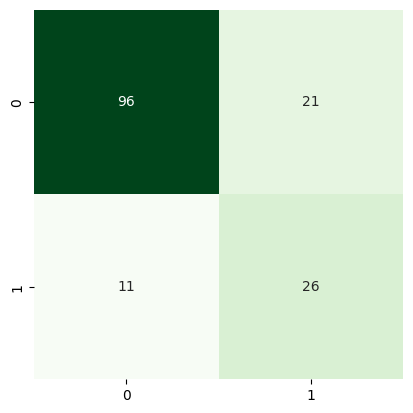

In [37]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 10)
knn.fit(x_train_pca,y_train)

knn_pred = knn.predict(x_test_pca)

knn_acc = accuracy_score(knn_pred,y_test)
print(knn_acc)

clf_report = classification_report(knn_pred,y_test)
print(clf_report)

cm = confusion_matrix(knn_pred,y_test)
sns.heatmap(cm, square=True, annot=True, cmap='Greens', fmt='d', cbar=False)

print('F1 is: ', f1_score(knn_pred,y_test))

0.8116883116883117
              precision    recall  f1-score   support

           0       0.91      0.84      0.87       116
           1       0.60      0.74      0.66        38

    accuracy                           0.81       154
   macro avg       0.75      0.79      0.76       154
weighted avg       0.83      0.81      0.82       154

F1 is:  0.6588235294117647


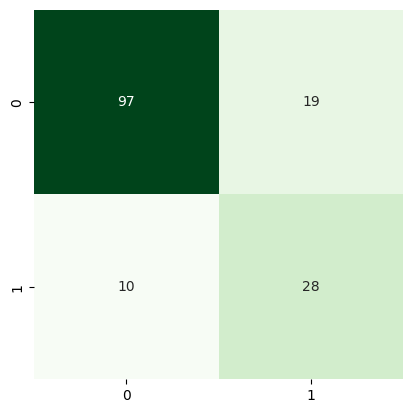

In [38]:
from sklearn.svm import SVC
svm = SVC()
svm.fit(x_train_pca,y_train)

svm_pred = svm.predict(x_test_pca)

svm_acc = accuracy_score(svm_pred,y_test)
print(svm_acc)

clf_report = classification_report(svm_pred,y_test)
print(clf_report)

cm = confusion_matrix(svm_pred,y_test)
sns.heatmap(cm, square=True, annot=True, cmap='Greens', fmt='d', cbar=False)

print('F1 is: ', f1_score(svm_pred,y_test))

0.7922077922077922
              precision    recall  f1-score   support

           0       0.89      0.83      0.86       115
           1       0.57      0.69      0.63        39

    accuracy                           0.79       154
   macro avg       0.73      0.76      0.74       154
weighted avg       0.81      0.79      0.80       154

F1 is:  0.627906976744186


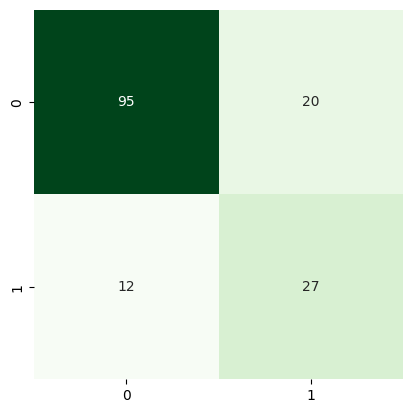

In [39]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(x_train_pca,y_train)

nb_pred = nb.predict(x_test_pca)

nb_acc = accuracy_score(nb_pred,y_test)
print(nb_acc)

clf_report = classification_report(nb_pred,y_test)
print(clf_report)

cm = confusion_matrix(nb_pred,y_test)
sns.heatmap(cm, square=True, annot=True, cmap='Greens', fmt='d', cbar=False)

print('F1 is: ', f1_score(nb_pred,y_test))

0.461038961038961
              precision    recall  f1-score   support

           0       0.41      0.69      0.51        64
           1       0.57      0.30      0.39        90

    accuracy                           0.46       154
   macro avg       0.49      0.49      0.45       154
weighted avg       0.51      0.46      0.44       154

F1 is:  0.39416058394160586


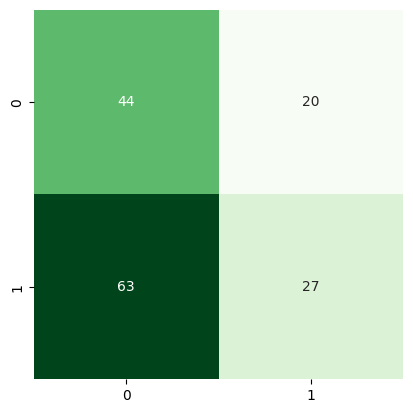

In [40]:
from sklearn.linear_model import SGDClassifier
sgd = SGDClassifier()
sgd.fit(x_train_pca,y_train)

sgd_pred = sgd.predict(x_test_pca)

sgd_acc = accuracy_score(sgd_pred,y_test)
print(sgd_acc)

clf_report = classification_report(sgd_pred,y_test)
print(clf_report)

cm = confusion_matrix(sgd_pred,y_test)
sns.heatmap(cm, square=True, annot=True, cmap='Greens', fmt='d', cbar=False)

print('F1 is: ', f1_score(sgd_pred,y_test))

In [41]:
models = []
from sklearn.metrics import accuracy_score

models.append(('KNN', KNeighborsClassifier()))
models.append(('DT', DecisionTreeClassifier()))
models.append(('RF', RandomForestClassifier()))
models.append(('LR', LogisticRegression()))
models.append(('SVC', SVC()))
models.append(('NB', GaussianNB()))
models.append(('SGD', SGDClassifier()))


names = []
scores = []
for name, model in models:
    model.fit(x_train_pca, y_train)
    y_pred = model.predict(x_test_pca)
    scores.append(accuracy_score(y_pred, y_test))
    names.append(name)
tr_split = pd.DataFrame({'Name': names, 'Score': scores})
print(tr_split)

  Name     Score
0  KNN  0.753247
1   DT  0.714286
2   RF  0.792208
3   LR  0.824675
4  SVC  0.811688
5   NB  0.792208
6  SGD  0.772727


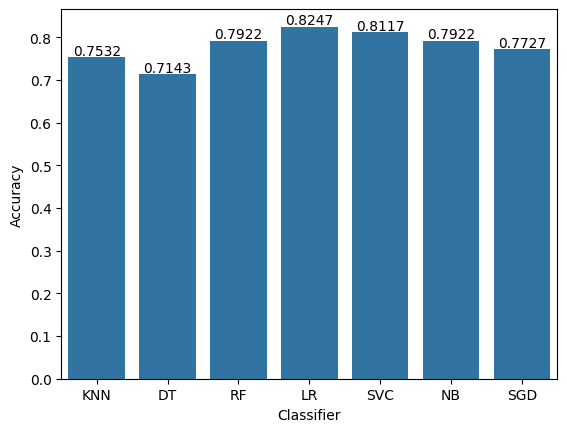

In [42]:

axis = sns.barplot(x = 'Name', y = 'Score', data =tr_split )
axis.set(xlabel='Classifier', ylabel='Accuracy')
for p in axis.patches:
    height = p.get_height()
    axis.text(p.get_x() + p.get_width()/2, height + 0.005, '{:1.4f}'.format(height), ha="center") 
    
plt.show()